# KAMP No.36 소성가공 압출공정 데이터 — Data Audit & Basic EDA

## Purpose

본 노트북은 `소성가공_압출공정_데이터셋.csv`의 데이터를 객관적으로 확인하고,
제공된 압출공정 도메인 설명과 데이터 기록이 어디에서 일치/불일치하는지 점검한다.

확인 항목:
- 파일 fingerprint와 재현 가능한 로딩
- 행/열, dtype, 의미상 역할
- 결측·특수값·중복·cardinality
- 5초 시계열의 순서와 간격
- 사후 비교 라벨의 구조
- 센서별 기록 해상도와 장기 동일값
- 사건 전후 거동과 도메인 가설
- 원계열/차분/추세 제거 후 관계
- 완충구간 민감도와 데이터 위험 지도

현재 단계에서 확정하지 않는 것:

- feature 삭제 또는 결측 대체
- `passorfail`을 예측 타겟으로 사용하는 결정
- 최종 검증 분할, 지표, 경보 임계값
- 모델 훈련
- 상관관계의 인과 해석
- 압력 0, H4, MD_TQ의 물리적 정체

## Domain Context Used as Hypotheses

제공된 도메인에서 다음 맥락이 존재한다.

- 해당 공정은 다중 압출 구조이며 EX1이 메인 압출기, EX2–EX5가 보조 압출기일 가능성
- Z는 가열 zone, A는 adaptor, H는 die/heater 계열, H2O는 냉각수 계열이라는 설명
- `MELT_P_PV`는 용융물 압력, `MD_PV`는 모터 속도, `MD_TQ`는 토크라는 설명
- `passorfail`은 사후 품질 판정이며 목표는 라벨 분류보다 정상 이탈 구간의 재정의

이 설명은 열 역할의 근거지만, CSV에 단위·태그 사전·센서 위치·라벨 생성 규칙이 없으므로
데이터가 설명과 다르게 기록된 경우에는 `TODO[NEEDS-CONFIRMATION]`으로 남긴다.

## 1. Imports and Reproducibility

이 셀은 실행 환경과 분석에 실제로 사용하는 라이브러리만 기록한다.

In [1]:
# Imports and Reproducibility
# 같은 입력에서 같은 Audit 결과를 만들기 위해 seed와 package version을 기록한다.
from pathlib import Path
from importlib.metadata import version
import hashlib
import platform
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython import get_ipython
from IPython.display import Markdown, display

# Jupyter와 in-process 재실행 검증 모두에서 figure output을 Notebook에 포함한다.
ipython_shell = get_ipython()
if ipython_shell is not None:
    ipython_shell.run_line_magic("matplotlib", "inline")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})

print("Python:", sys.version.split()[0])
print("OS:", platform.platform())
print("pandas:", version("pandas"))
print("numpy:", version("numpy"))
print("matplotlib:", version("matplotlib"))
print("random seed:", RANDOM_SEED)
environment_summary = pd.Series({
    "Python": sys.version.split()[0],
    "OS": platform.platform(),
    "pandas": version("pandas"),
    "numpy": version("numpy"),
    "matplotlib": version("matplotlib"),
    "random_seed": RANDOM_SEED,
}, name="value")
display(environment_summary.to_frame())

# Checkpoint
# 실행 환경 정보가 출력되었는가?

,value
Python,3.12.13
OS,Linux-6.18.35-x86_64-with-glibc2.39
pandas,2.2.3
numpy,2.3.5
matplotlib,3.10.8
random_seed,42


## 2. Configuration and Paths


In [2]:
# Configuration and Paths
DATA_FILENAME = "소성가공_압출공정_데이터셋.csv"
EXPECTED_SHA256 = "45b85546fdae1afef138aac1e1fe7deb3bb48d2b20a53db98139014bc2887291"
TARGET_LIKE_COL = "passorfail"  # 사후 비교 라벨이며, 예측 타겟 확정이 아님


def find_data_path(filename: str) -> Path:
    '''현재 위치와 상위 폴더의 일반적인 raw-data 위치에서 파일을 찾는다.'''
    relative_candidates = [
        Path(filename),
        Path("data") / "raw" / filename,
        Path("upload") / filename,
    ]
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        for relative_path in relative_candidates:
            candidate = base / relative_path
            if candidate.is_file():
                return candidate
    raise FileNotFoundError(
        f"{filename}을 찾지 못했습니다. Notebook과 같은 폴더 또는 data/raw에 두세요."
    )


DATA_PATH = find_data_path(DATA_FILENAME)
DATA_SHA256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()

print("Data path:", DATA_PATH)
print("Data exists:", DATA_PATH.exists())
print("SHA-256:", DATA_SHA256)
print("Fingerprint matches expected file:", DATA_SHA256 == EXPECTED_SHA256)
display(pd.Series({
    "data_file": DATA_PATH.name,
    "detected_parent_folder": DATA_PATH.parent.name,
    "data_exists": DATA_PATH.exists(),
    "sha256": DATA_SHA256,
    "fingerprint_matches": DATA_SHA256 == EXPECTED_SHA256,
}, name="value").to_frame())

if DATA_SHA256 != EXPECTED_SHA256:
    print("CAUTION: 같은 파일명이나 byte 내용이 다른 데이터입니다. 결과를 원 보고서와 직접 비교하지 마세요.")

# Checkpoint
# 파일명이 같아도 fingerprint가 다르면 다른 데이터일 수 있다.

,value
data_file,소성가공_압출공정_데이터셋.csv
detected_parent_folder,upload
data_exists,True
sha256,45b85546fdae1afef138aac1e1fe7deb3bb48d2b20a53d...
fingerprint_matches,True


## 3. Data Loading Checkpoint

CSV loader와 timestamp format을 명시한다. 원본 `date` 열은 보존하고 별도 `timestamp`를 만든다.

In [3]:
# Data Loading
# Domain connection: 한 행은 5초 시점의 공정 snapshot 후보다. timestamp를 먼저 검증해야 한다.
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
df["timestamp"] = pd.to_datetime(
    df["date"], format="%Y %m %d %H:%M:%S", errors="coerce"
)

display(df_raw.head())
print("Raw shape:", df_raw.shape)

# Checkpoint
# header가 한 행으로 읽혔고 여러 sensor column이 분리되어 보이는가?
# 불필요한 저장 index column이 추가되어 있지 않은가?

,date,EX5.MELT_TEMP,EX4.MELT_TEMP,EX3.MELT_TEMP,EX2.MELT_TEMP,EX1.Z1_PV,EX1.Z2_PV,EX1.Z3_PV,EX1.Z4_PV,EX1.A1_PV,EX1.A2_PV,EX1.H1_PV,EX1.H2_PV,EX1.H3_PV,EX1.H4_PV,EX1.H2O_PV,EX1.MELT_P_PV,EX1.MD_PV,EX1.MD_TQ,passorfail
0,2020 10 30 00:00:04,297,222,251,267,209,219,229,239,240,239,241,240,240,40,41,0.0,71.2215,72,0.0
1,2020 10 30 00:00:09,297,222,251,268,210,219,229,239,240,239,240,240,240,40,41,0.0,71.2096,72,0.0
2,2020 10 30 00:00:14,297,222,251,267,210,219,229,239,240,239,240,240,240,40,41,0.0,71.1977,72,0.0
3,2020 10 30 00:00:19,297,222,251,267,210,219,229,240,240,239,241,240,240,40,41,0.0,71.1977,72,0.0
4,2020 10 30 00:00:24,297,222,251,267,210,219,229,239,240,239,241,240,240,40,41,0.0,71.1977,72,0.0


## 4. Dataset Structure Audit

pandas 저장 타입과 분석상 역할은 다르다. 예를 들어 `MD_TQ`는 정수형이지만
실제 파일에서는 이산 상태처럼 동작할 수 있다.

In [4]:
# Dataset Structure Audit
print("Rows:", len(df_raw))
print("Columns:", len(df_raw.columns))
print("Column names:")
print(df_raw.columns.tolist())
print("\nPhysical dtypes:")
print(df_raw.dtypes.value_counts())
print("\nDetailed info:")
df_raw.info()
display(pd.Series({
    "rows": len(df_raw),
    "columns": len(df_raw.columns),
    "numeric_columns": len(df_raw.select_dtypes(include=np.number).columns),
    "text_columns": len(df_raw.select_dtypes(include=["object", "string", "category"]).columns),
}, name="count").to_frame())

# Checkpoint
# raw shape는 17,280 × 20인가?
# date/passorfail 외 18개 sensor 열이 숫자로 읽혔는가?

,count
rows,17280
columns,20
numeric_columns,19
text_columns,1


In [5]:
# Schema and Semantic Roles
# Domain connection: 첨부 설명을 역할 후보의 근거로 쓰되 공식 tag dictionary가 아님을 표시한다.
role_map = {
    "date": ("time", "데이터 사실", "고유 timestamp; 모델 feature 사용 시 시간 누수 위험"),
    "EX5.MELT_TEMP": ("aux_extruder_melt_temperature_candidate", "사용자 도메인 자료", "EX5 위치·단위 확인 필요"),
    "EX4.MELT_TEMP": ("aux_extruder_melt_temperature_candidate", "사용자 도메인 자료", "EX4 위치·단위 확인 필요"),
    "EX3.MELT_TEMP": ("aux_extruder_melt_temperature_candidate", "사용자 도메인 자료", "EX3 위치·단위 확인 필요"),
    "EX2.MELT_TEMP": ("aux_extruder_melt_temperature_candidate", "사용자 도메인 자료", "EX2 위치·단위 확인 필요"),
    "EX1.Z1_PV": ("main_extruder_zone_temperature_candidate", "사용자 도메인 자료", "Z1 위치·단위 확인 필요"),
    "EX1.Z2_PV": ("main_extruder_zone_temperature_candidate", "사용자 도메인 자료", "Z2 위치·단위 확인 필요"),
    "EX1.Z3_PV": ("main_extruder_zone_temperature_candidate", "사용자 도메인 자료", "Z3 위치·단위 확인 필요"),
    "EX1.Z4_PV": ("main_extruder_zone_temperature_candidate", "사용자 도메인 자료", "Z4 위치·단위 확인 필요"),
    "EX1.A1_PV": ("adaptor_temperature_candidate", "사용자 도메인 자료", "A1 위치·단위 확인 필요"),
    "EX1.A2_PV": ("adaptor_temperature_candidate", "사용자 도메인 자료", "A2 위치·단위 확인 필요"),
    "EX1.H1_PV": ("die_or_heater_temperature_candidate", "사용자 도메인 자료", "H1 위치 확인 필요"),
    "EX1.H2_PV": ("die_or_heater_temperature_candidate", "사용자 도메인 자료", "H2 위치 확인 필요"),
    "EX1.H3_PV": ("die_or_heater_temperature_candidate", "사용자 도메인 자료", "H3 위치 확인 필요"),
    "EX1.H4_PV": ("unknown_temperature_like_signal", "이름+데이터", "H1–H3와 약 200 차이; 냉각부 가능성은 미확정"),
    "EX1.H2O_PV": ("cooling_water_temperature_candidate", "사용자 도메인 자료", "위치·단위 확인 필요"),
    "EX1.MELT_P_PV": ("melt_pressure_candidate", "사용자 도메인 자료", "0값의 물리적 의미 미확정"),
    "EX1.MD_PV": ("motor_speed_candidate", "사용자 도메인 자료", "사건 주변 큰 레짐 변화"),
    "EX1.MD_TQ": ("torque_or_status_candidate", "설명+데이터", "이 파일에서는 0/72 두 값뿐"),
    "passorfail": ("posthoc_comparison_label", "사용자 문제 정의", "타겟 아님; 생성/경계 규칙 확인 필요"),
}

schema_rows = []
for column in df_raw.columns:
    role, source, note = role_map[column]
    values = df_raw[column].dropna().unique()[:4]
    schema_rows.append({
        "column": column,
        "dtype": str(df_raw[column].dtype),
        "non_null": int(df_raw[column].notna().sum()),
        "missing_count": int(df_raw[column].isna().sum()),
        "missing_pct": float(df_raw[column].isna().mean() * 100),
        "unique_count": int(df_raw[column].nunique(dropna=False)),
        "unique_pct": float(df_raw[column].nunique(dropna=False) / len(df_raw) * 100),
        "sample_values": ", ".join(map(str, values)),
        "suggested_role": role,
        "role_source": source,
        "review_note": note,
    })

schema_table = pd.DataFrame(schema_rows)
display(schema_table)

# Checkpoint
# suggested_role은 데이터 사전이 아니라 검토용 후보다.

,column,dtype,non_null,missing_count,missing_pct,unique_count,unique_pct,sample_values,suggested_role,role_source,review_note
0,date,object,17280,0,0.000000,17280,100.000000,"2020 10 30 00:00:04, 2020 10 30 00:00:09, 2020...",time,데이터 사실,고유 timestamp; 모델 feature 사용 시 시간 누수 위험
1,EX5.MELT_TEMP,int64,17280,0,0.000000,7,0.040509,"297, 296, 298, 295",aux_extruder_melt_temperature_candidate,사용자 도메인 자료,EX5 위치·단위 확인 필요
2,EX4.MELT_TEMP,int64,17280,0,0.000000,4,0.023148,"222, 221, 219, 223",aux_extruder_melt_temperature_candidate,사용자 도메인 자료,EX4 위치·단위 확인 필요
3,EX3.MELT_TEMP,int64,17280,0,0.000000,5,0.028935,"251, 252, 250, 253",aux_extruder_melt_temperature_candidate,사용자 도메인 자료,EX3 위치·단위 확인 필요
4,EX2.MELT_TEMP,int64,17280,0,0.000000,5,0.028935,"267, 268, 266, 269",aux_extruder_melt_temperature_candidate,사용자 도메인 자료,EX2 위치·단위 확인 필요
5,EX1.Z1_PV,int64,17280,0,0.000000,18,0.104167,"209, 210, 211, 212",main_extruder_zone_temperature_candidate,사용자 도메인 자료,Z1 위치·단위 확인 필요
6,EX1.Z2_PV,int64,17280,0,0.000000,5,0.028935,"219, 220, 218, 217",main_extruder_zone_temperature_candidate,사용자 도메인 자료,Z2 위치·단위 확인 필요
7,EX1.Z3_PV,int64,17280,0,0.000000,5,0.028935,"229, 230, 228, 231",main_extruder_zone_temperature_candidate,사용자 도메인 자료,Z3 위치·단위 확인 필요
8,EX1.Z4_PV,int64,17280,0,0.000000,6,0.034722,"239, 240, 238, 241",main_extruder_zone_temperature_candidate,사용자 도메인 자료,Z4 위치·단위 확인 필요
9,EX1.A1_PV,int64,17280,0,0.000000,3,0.017361,"240, 239, 241",adaptor_temperature_candidate,사용자 도메인 자료,A1 위치·단위 확인 필요


## 5. Missing and Sentinel Audit

실제 `NaN`과 0 같은 관측값을 분리한다. 0을 결측으로 볼지는 빈도·시간 연결성·도메인 의미가 필요하다.

In [6]:
# Missing Value Audit
# Domain connection: 압력 0이나 모터 0은 공정 상태일 수 있으므로 자동 치환하지 않는다.
missing_table = pd.DataFrame({
    "missing_count": df_raw.isna().sum(),
    "missing_pct": df_raw.isna().mean() * 100,
}).sort_values("missing_count", ascending=False)
display(missing_table)

numeric_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
special_value_table = pd.DataFrame({
    "zero_count": [(df_raw[c] == 0).sum() for c in numeric_cols],
    "zero_pct": [(df_raw[c] == 0).mean() * 100 for c in numeric_cols],
    "infinite_count": [np.isinf(df_raw[c].dropna()).sum() for c in numeric_cols],
}, index=numeric_cols).sort_values("zero_count", ascending=False)
display(special_value_table.head(8))

object_cols = df_raw.select_dtypes(include=["object", "string", "category"]).columns
placeholder_tokens = {"?", "unknown", "UNKNOWN", "-999", "9999", ""}
placeholder_counts = {
    c: int(df_raw[c].astype("string").isin(placeholder_tokens).sum()) for c in object_cols
}
print("Text placeholder token counts:", placeholder_counts)

# Checkpoint
# 센서 결측은 0개이며 passorfail 마지막 16행만 비어 있는가?
# 0값은 결측으로 처리하지 않은 상태인가?

,missing_count,missing_pct
passorfail,16,0.092593
date,0,0.000000
EX4.MELT_TEMP,0,0.000000
EX5.MELT_TEMP,0,0.000000
EX3.MELT_TEMP,0,0.000000
EX2.MELT_TEMP,0,0.000000
EX1.Z2_PV,0,0.000000
EX1.Z1_PV,0,0.000000
EX1.Z4_PV,0,0.000000
EX1.A1_PV,0,0.000000


,zero_count,zero_pct,infinite_count
passorfail,17154,99.270833,0
EX1.MELT_P_PV,4400,25.462963,0
EX1.MD_PV,27,0.156250,0
EX1.MD_TQ,25,0.144676,0
EX3.MELT_TEMP,0,0.000000,0
EX5.MELT_TEMP,0,0.000000,0
EX4.MELT_TEMP,0,0.000000,0
EX2.MELT_TEMP,0,0.000000,0


## 6. Duplicate Audit

timestamp가 달라 같은 센서 상태가 반복되는 것은 공정의 지속시간 정보일 수 있다.
완전 중복과 센서 벡터 반복을 따로 센다.

In [7]:
# Duplicate Audit
measurement_cols = [
    c for c in df_raw.columns if c not in ["date", TARGET_LIKE_COL]
]
full_duplicates = int(df_raw.duplicated().sum())
timestamp_duplicates = int(df_raw["date"].duplicated().sum())
measurement_vector_duplicates = int(df_raw.duplicated(measurement_cols).sum())
consecutive_equal_vectors = int(
    df_raw[measurement_cols].eq(df_raw[measurement_cols].shift()).all(axis=1).sum()
)

duplicate_summary = pd.Series({
    "full_duplicate_rows": full_duplicates,
    "duplicate_timestamps": timestamp_duplicates,
    "repeated_measurement_vector_rows": measurement_vector_duplicates,
    "unique_measurement_vectors": int(df_raw[measurement_cols].drop_duplicates().shape[0]),
    "consecutive_equal_measurement_vectors": consecutive_equal_vectors,
}, name="count")
display(duplicate_summary.to_frame())

# Domain connection: 반복 벡터 삭제는 5초 상태 지속시간을 훼손한다.
# Checkpoint
# random row split에서는 비슷한 인접 관측이 훈련/검증에 섞일 수 있다.

,count
full_duplicate_rows,0
duplicate_timestamps,0
repeated_measurement_vector_rows,2426
unique_measurement_vectors,14854
consecutive_equal_measurement_vectors,925


## 7. Cardinality and Recording Resolution

고유값 수, 최빈값 집중, 값 변경 빈도, 동일값 연속 유지시간을 함께 본다.
낮은 cardinality는 곧 범주형이라는 뜻이 아니라 기록 해상도 또는 제어 특성일 수 있다.

In [8]:
# Cardinality and Recording Resolution Audit
# Domain connection: 제어 온도는 자연스럽게 장시간 일정할 수 있으므로 sensor freeze와 구분해야 한다.
SAMPLE_SECONDS = 5


def state_runs(values: pd.Series, timestamps: pd.Series) -> pd.DataFrame:
    '''연속 동일 상태의 시작·끝·행 수를 계산한다.'''
    series = values.reset_index(drop=True)
    time_series = timestamps.reset_index(drop=True)
    group_key = series.ne(series.shift()).cumsum()
    rows = []
    frame = pd.DataFrame({"value": series, "timestamp": time_series, "group": group_key})
    for _, group in frame.groupby("group", sort=False):
        rows.append({
            "value": group["value"].iloc[0],
            "start": group["timestamp"].iloc[0],
            "end": group["timestamp"].iloc[-1],
            "rows": len(group),
            "duration_seconds_by_rows": len(group) * SAMPLE_SECONDS,
        })
    return pd.DataFrame(rows)


cardinality_rows = []
for column in measurement_cols:
    value_counts = df_raw[column].value_counts(dropna=False)
    runs = state_runs(df_raw[column], df["timestamp"])
    unique_values = np.sort(df_raw[column].dropna().unique())
    positive_steps = np.diff(unique_values)
    positive_steps = positive_steps[positive_steps > 0]
    cardinality_rows.append({
        "column": column,
        "unique_count": int(df_raw[column].nunique(dropna=False)),
        "top_value": value_counts.index[0],
        "top_value_pct": float(value_counts.iloc[0] / len(df_raw) * 100),
        "change_pct": float(df_raw[column].ne(df_raw[column].shift()).iloc[1:].mean() * 100),
        "median_run_rows": float(runs["rows"].median()),
        "max_run_rows": int(runs["rows"].max()),
        "max_run_minutes": float(runs["duration_seconds_by_rows"].max() / 60),
        "minimum_positive_step": float(positive_steps.min()) if len(positive_steps) else np.nan,
    })

cardinality_table = pd.DataFrame(cardinality_rows).sort_values("unique_count")
display(cardinality_table.round(4))

# Checkpoint
# MD_TQ가 2개 값뿐이고 EX5의 최장 동일값이 4,128행인가?

,column,unique_count,top_value,top_value_pct,change_pct,median_run_rows,max_run_rows,max_run_minutes,minimum_positive_step
17,EX1.MD_TQ,2,72.0000,99.8553,0.0116,7564.0,9691,807.5833,72.0000
8,EX1.A1_PV,3,240.0000,56.8692,6.2735,3.0,164,13.6667,1.0000
1,EX4.MELT_TEMP,4,222.0000,85.2894,3.2872,2.0,2089,174.0833,1.0000
3,EX2.MELT_TEMP,5,267.0000,73.9699,2.3844,3.0,1351,112.5833,1.0000
6,EX1.Z3_PV,5,230.0000,67.5000,17.6804,2.0,224,18.6667,1.0000
5,EX1.Z2_PV,5,220.0000,61.6609,7.3673,2.0,213,17.7500,1.0000
11,EX1.H2_PV,5,240.0000,58.0498,10.1453,2.0,243,20.2500,1.0000
2,EX3.MELT_TEMP,5,251.0000,67.2396,3.7792,3.0,469,39.0833,1.0000
9,EX1.A2_PV,6,240.0000,52.2859,6.5339,6.0,114,9.5000,1.0000
10,EX1.H1_PV,6,240.0000,56.0764,9.1498,2.0,240,20.0000,1.0000


## 8. Numeric Summary and Time Integrity

최소/최대는 단위와 물리 범위가 없으므로 내부 일관성만 확인한다.
이어서 5초 간격이 하루 전체에서 유지되는지 검증한다.

In [9]:
# Numeric Summary
numeric_feature_cols = [c for c in measurement_cols if pd.api.types.is_numeric_dtype(df_raw[c])]
numeric_summary = df_raw[numeric_feature_cols].describe().T[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]
display(numeric_summary.round(4))

# Domain connection: H4와 H1–H3의 약 200 차이는 동일한 die-zone 묶음이라는 설명을 재검토하게 한다.
# Checkpoint
# 단위 정보가 없으므로 값 범위를 물리적으로 정상/이상이라고 단정하지 않는다.

,count,mean,std,min,25%,50%,75%,max
EX5.MELT_TEMP,17280.0,296.3903,0.5880,294.0,296.0000,296.0000,297.0000,300.0000
EX4.MELT_TEMP,17280.0,221.8922,0.3694,219.0,222.0000,222.0000,222.0000,223.0000
EX3.MELT_TEMP,17280.0,251.0215,0.6374,249.0,251.0000,251.0000,251.0000,253.0000
EX2.MELT_TEMP,17280.0,266.9293,0.5779,265.0,267.0000,267.0000,267.0000,269.0000
EX1.Z1_PV,17280.0,209.7865,1.6282,201.0,209.0000,210.0000,210.0000,218.0000
EX1.Z2_PV,17280.0,219.6194,0.4963,217.0,219.0000,220.0000,220.0000,221.0000
EX1.Z3_PV,17280.0,229.6780,0.4735,228.0,229.0000,230.0000,230.0000,232.0000
EX1.Z4_PV,17280.0,239.6763,0.4778,237.0,239.0000,240.0000,240.0000,242.0000
EX1.A1_PV,17280.0,239.5761,0.5016,239.0,239.0000,240.0000,240.0000,241.0000
EX1.A2_PV,17280.0,239.5721,0.5865,237.0,239.0000,240.0000,240.0000,242.0000


In [10]:
# Time Integrity Audit
time_deltas = df["timestamp"].diff()
time_summary = pd.Series({
    "parse_failures": int(df["timestamp"].isna().sum()),
    "duplicate_timestamps": int(df["timestamp"].duplicated().sum()),
    "monotonic_increasing": bool(df["timestamp"].is_monotonic_increasing),
    "start": df["timestamp"].min(),
    "end": df["timestamp"].max(),
    "rows": len(df),
    "five_second_intervals": int(time_deltas.eq(pd.Timedelta(seconds=5)).sum()),
    "non_five_second_intervals": int((time_deltas.dropna() != pd.Timedelta(seconds=5)).sum()),
}, name="result")
display(time_summary.to_frame())

# Domain connection: 인접 행은 5초 간격의 자기상관된 공정 상태이므로 독립 표본으로 볼 수 없다.
# Checkpoint
# 17,279개 간격이 모두 5초인가?

,result
parse_failures,0
duplicate_timestamps,0
monotonic_increasing,True
start,2020-10-30 00:00:04
end,2020-10-30 23:59:59
rows,17280
five_second_intervals,17279
non_five_second_intervals,0


## 9. Comparison Label Audit

`passorfail`은 사후 비교 라벨로만 사용한다. 양성행 수뿐 아니라 연속 구간과 내부 공백을 확인한다.

,count,pct_all_rows
passorfail,,
0.0,17154,99.270833
1.0,110,0.636574
NaN,16,0.092593


,display_value,start,end,rows,duration_seconds_by_rows
0,0.0,2020-10-30 00:00:04,2020-10-30 13:26:14,9675,48375
1,1.0,2020-10-30 13:26:19,2020-10-30 13:30:44,54,270
2,0.0,2020-10-30 13:30:49,2020-10-30 13:30:54,2,10
3,1.0,2020-10-30 13:30:59,2020-10-30 13:35:34,56,280
4,0.0,2020-10-30 13:35:39,2020-10-30 23:58:39,7477,37385
5,MISSING,2020-10-30 23:58:44,2020-10-30 23:59:59,16,80


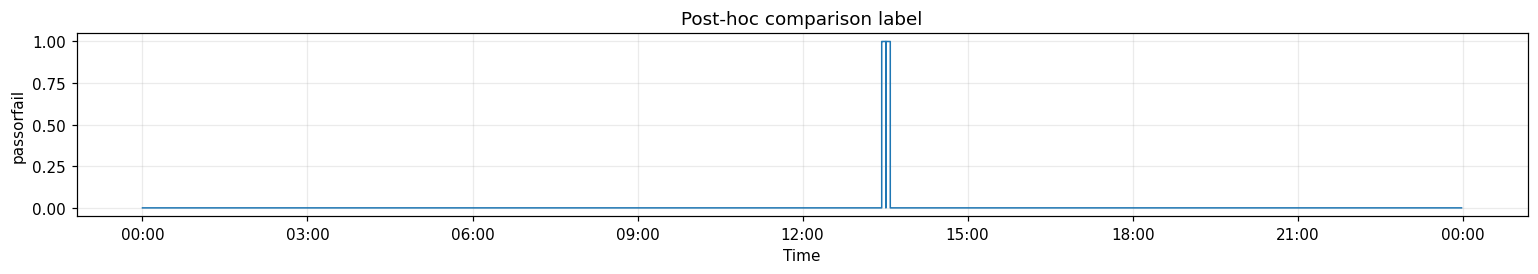

In [11]:
# Label Distribution and Contiguous Runs
label_counts = df[TARGET_LIKE_COL].value_counts(dropna=False).rename("count").to_frame()
label_counts["pct_all_rows"] = label_counts["count"] / len(df) * 100
display(label_counts)

label_for_runs = df[TARGET_LIKE_COL].fillna(-1)
label_runs = state_runs(label_for_runs, df["timestamp"])
label_runs["display_value"] = label_runs["value"].replace({-1.0: "MISSING"})
display(label_runs[["display_value", "start", "end", "rows", "duration_seconds_by_rows"]])

positive_mask = df[TARGET_LIKE_COL].eq(1)
event_start = df.loc[positive_mask, "timestamp"].min()
event_end = df.loc[positive_mask, "timestamp"].max()
positive_pct_nonmissing = positive_mask.sum() / df[TARGET_LIKE_COL].notna().sum() * 100

print("Positive rows:", int(positive_mask.sum()))
print("Positive pct among observed labels:", round(positive_pct_nonmissing, 4), "%")
print("First positive:", event_start)
print("Last positive:", event_end)

fig, ax = plt.subplots(figsize=(14, 2.6))
ax.step(df["timestamp"], df[TARGET_LIKE_COL], where="post", linewidth=1.0)
ax.set(title="Post-hoc comparison label", xlabel="Time", ylabel="passorfail")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

# Domain connection: 두 양성 구간 사이 10초의 0을 하나의 사건으로 병합하려면 사전 규칙이 필요하다.
# Checkpoint
# 양성 110행이 두 연속 구간으로 나뉘며 마지막 16행은 결측인가?

## 10. Full-day Sensor Overview

전체 추세, 장기 동일값, 사건 주변의 큰 상태 변화를 한 번에 확인한다.
붉은 영역은 첫 양성부터 마지막 양성까지의 envelope이며, 인과 구간을 뜻하지 않는다.

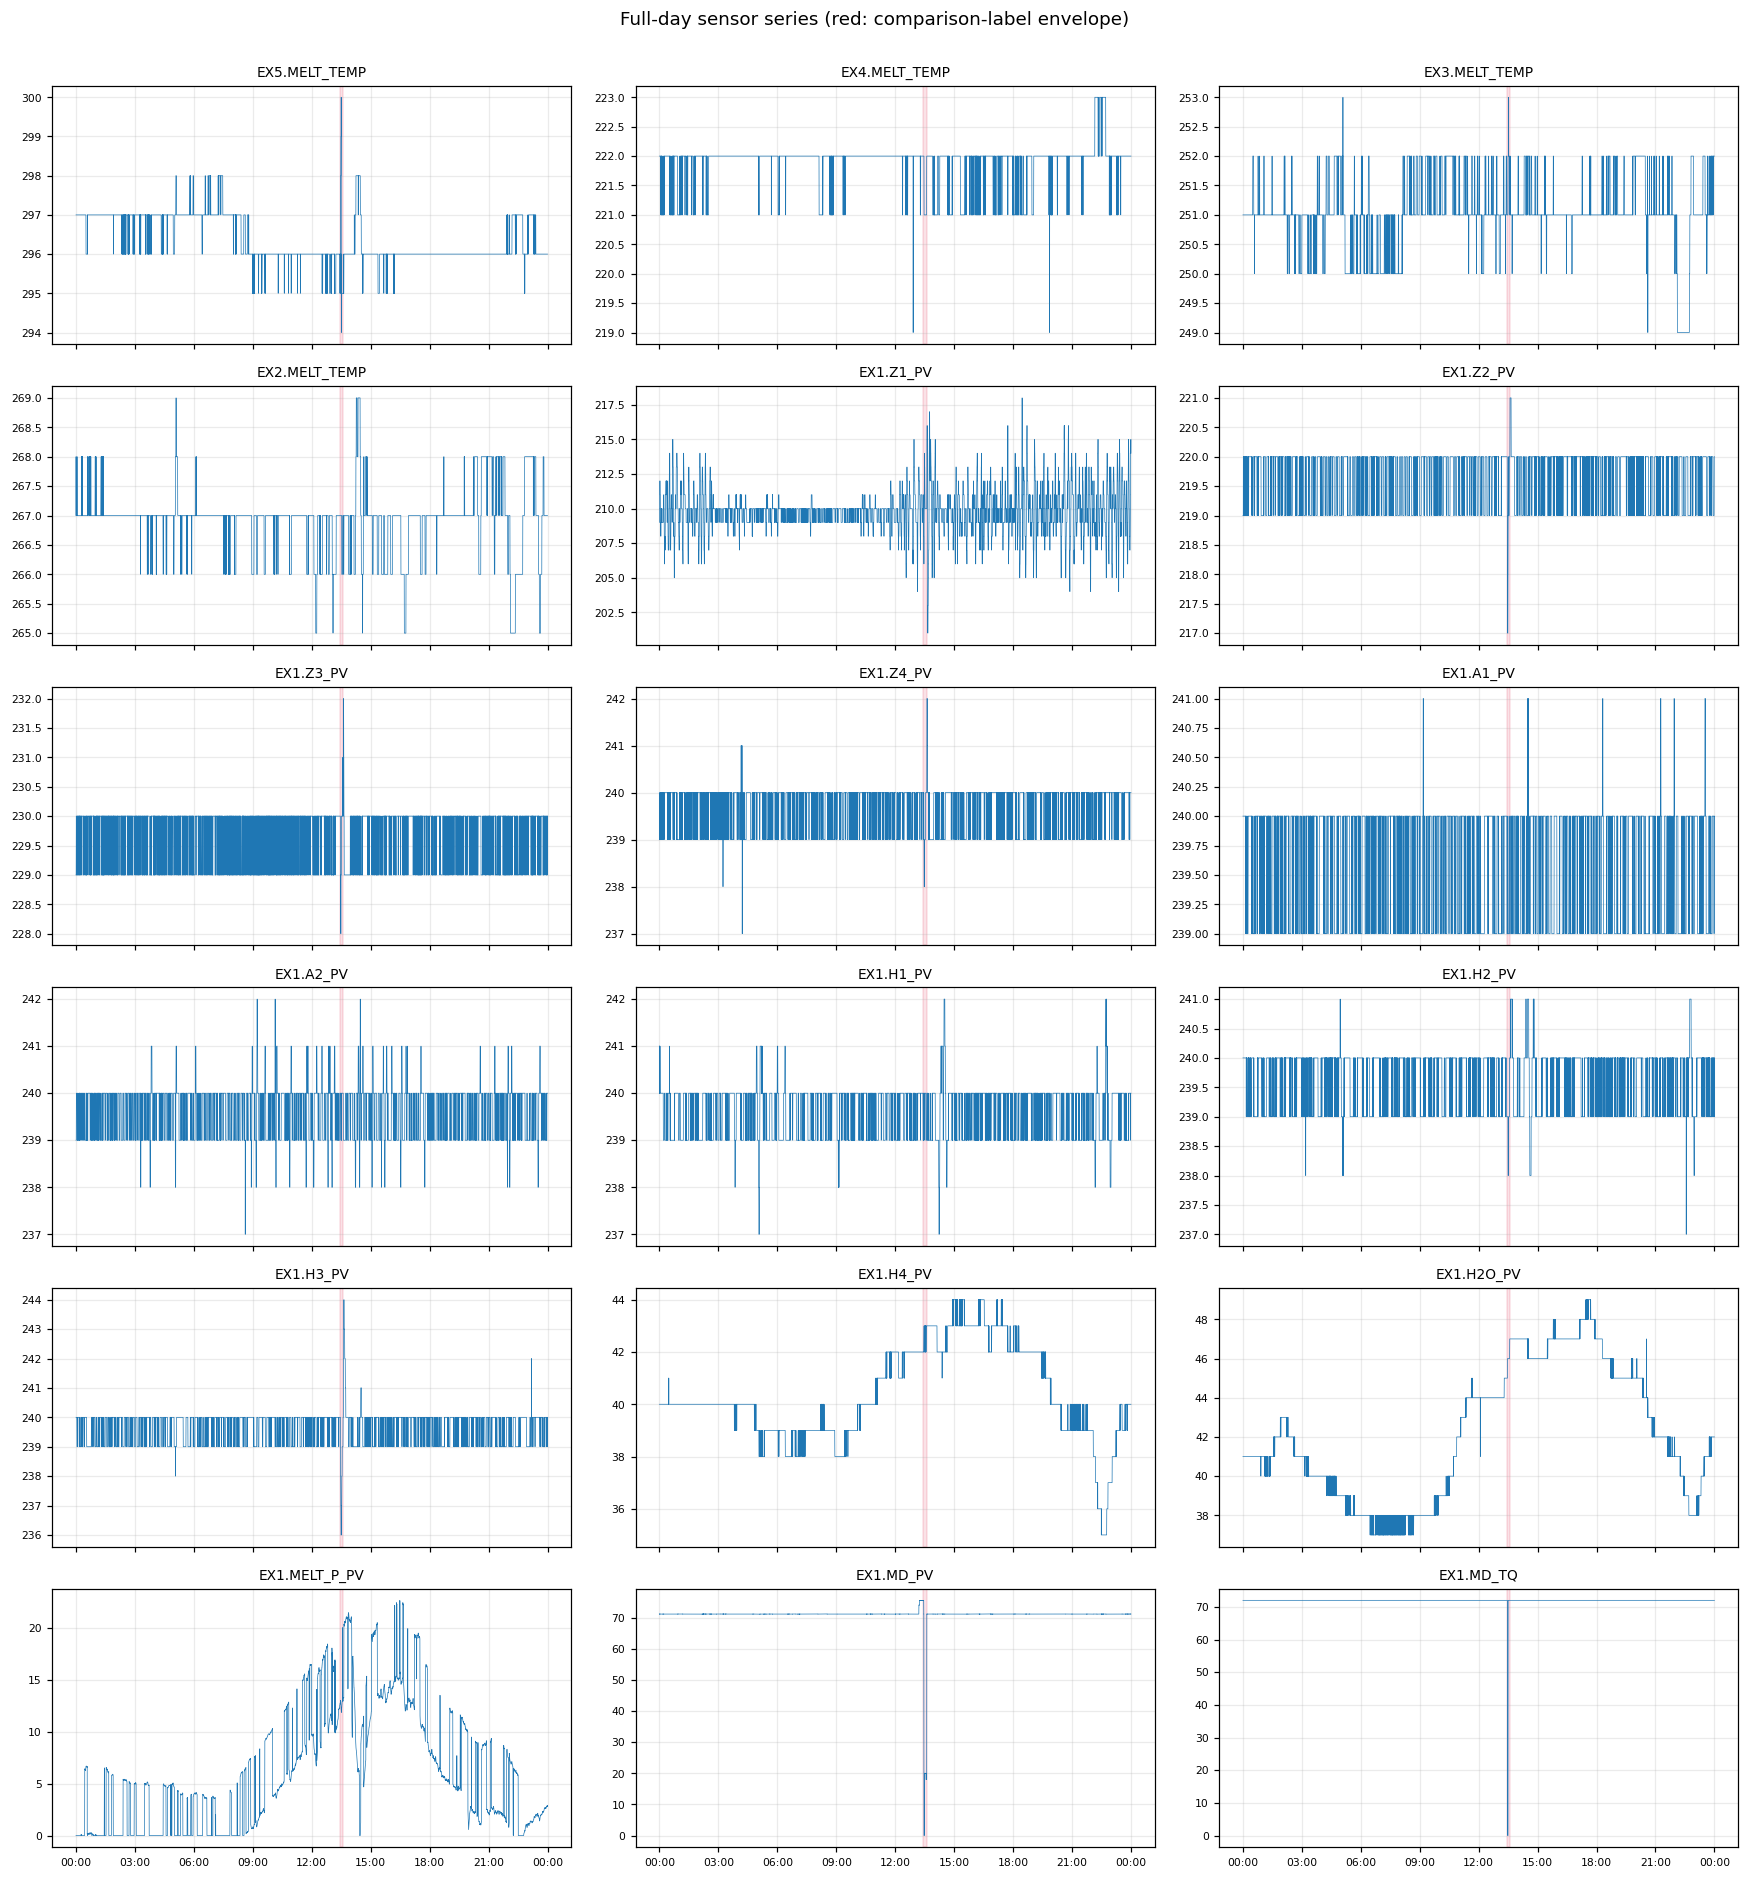

In [12]:
# Full-day Time-Series Overview
# Domain connection: 5초 공정 신호는 histogram만으로 시간적 레짐을 볼 수 없으므로 원순서를 보존한다.
fig, axes = plt.subplots(6, 3, figsize=(16, 17), sharex=True)
for axis, column in zip(axes.flat, measurement_cols):
    axis.plot(df["timestamp"], df[column], linewidth=0.45)
    axis.axvspan(event_start, event_end, color="crimson", alpha=0.12)
    axis.set_title(column, fontsize=9)
    axis.tick_params(labelsize=7)
for axis in axes[-1, :]:
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.suptitle("Full-day sensor series (red: comparison-label envelope)", y=1.002)
plt.tight_layout()
plt.show()

# Checkpoint
# EX5/H4/H2O/pressure의 느린 추세와 MD_PV의 사건 주변 급변이 보이는가?

## 11. Domain Integrity Checks

도메인 설명과 실제 기록이 충돌하는 핵심 항목을 수치로 분리한다.

In [13]:
# Domain Integrity: MD_TQ, pressure zero, H4, EX5
md_tq_counts = df["EX1.MD_TQ"].value_counts().sort_index()
md_tq_mdpv_crosstab = pd.crosstab(
    df["EX1.MD_TQ"], df["EX1.MD_PV"].eq(0),
    rownames=["MD_TQ"], colnames=["MD_PV_is_zero"], margins=True
)
display(md_tq_counts.rename("rows").to_frame())
display(md_tq_mdpv_crosstab)

pressure_zero_mask = df["EX1.MELT_P_PV"].eq(0)
pressure_zero_runs = state_runs(pressure_zero_mask, df["timestamp"])
pressure_zero_runs = pressure_zero_runs[pressure_zero_runs["value"]].reset_index(drop=True)

ex5_runs = state_runs(df["EX5.MELT_TEMP"], df["timestamp"])
ex5_longest = ex5_runs.sort_values("rows", ascending=False).iloc[0]

integrity_summary = pd.Series({
    "MD_TQ_unique_values": int(df["EX1.MD_TQ"].nunique()),
    "MD_TQ_zero_rows": int(df["EX1.MD_TQ"].eq(0).sum()),
    "MD_TQ_zero_and_MD_PV_zero_rows": int((df["EX1.MD_TQ"].eq(0) & df["EX1.MD_PV"].eq(0)).sum()),
    "pressure_zero_rows": int(pressure_zero_mask.sum()),
    "pressure_zero_pct": float(pressure_zero_mask.mean() * 100),
    "pressure_zero_runs": int(len(pressure_zero_runs)),
    "pressure_zero_max_minutes": float(pressure_zero_runs["duration_seconds_by_rows"].max() / 60),
    "MD_PV_mean_when_pressure_zero": float(df.loc[pressure_zero_mask, "EX1.MD_PV"].mean()),
    "H1_H3_mean": float(df[["EX1.H1_PV", "EX1.H2_PV", "EX1.H3_PV"]].stack().mean()),
    "H4_mean": float(df["EX1.H4_PV"].mean()),
    "H2O_mean": float(df["EX1.H2O_PV"].mean()),
    "EX5_longest_constant_value": ex5_longest["value"],
    "EX5_longest_constant_start": ex5_longest["start"],
    "EX5_longest_constant_end": ex5_longest["end"],
    "EX5_longest_constant_rows": int(ex5_longest["rows"]),
}, name="result")
display(integrity_summary.to_frame())

# Domain connection: MD_TQ의 binary-like 기록은 torque×speed 파생변수의 물리적 해석을 무너뜨린다.
# Domain connection: H4를 H1–H3 균일도에 자동 포함하면 약 200의 scale 차이만 측정하게 된다.
# Checkpoint
# pressure 0은 장기 반복되고 MD_PV는 정상 속도 수준을 유지하는가?

,rows
EX1.MD_TQ,
0,25
72,17255


MD_PV_is_zero,False,True,All
MD_TQ,,,
0,0,25,25
72,17253,2,17255
All,17253,27,17280


,result
MD_TQ_unique_values,2
MD_TQ_zero_rows,25
MD_TQ_zero_and_MD_PV_zero_rows,25
pressure_zero_rows,4400
pressure_zero_pct,25.462963
pressure_zero_runs,36
pressure_zero_max_minutes,43.333333
MD_PV_mean_when_pressure_zero,71.200542
H1_H3_mean,239.605748
H4_mean,40.372338


In [14]:
# Change Frequency Audit for Temperature Zones
# Domain connection: Z3의 민감성 가설을 값 변경 빈도와 평균 유지시간으로 확인한다.
zone_cols = ["EX1.Z2_PV", "EX1.Z3_PV", "EX1.Z4_PV"]
zone_change_table = cardinality_table.set_index("column").loc[
    zone_cols, ["change_pct", "median_run_rows", "max_run_rows"]
].copy()
zone_change_table["approx_mean_seconds_between_changes"] = [
    SAMPLE_SECONDS / (df[c].ne(df[c].shift()).iloc[1:].mean()) for c in zone_cols
]
display(zone_change_table.round(2))

# Checkpoint
# Z3의 값 변경 비율이 Z2보다 약 2배 이상인가?
# 물리적 민감성은 sensor 위치 확인 전까지 확정하지 않는다.

,change_pct,median_run_rows,max_run_rows,approx_mean_seconds_between_changes
column,,,,
EX1.Z2_PV,7.37,2.0,213,67.87
EX1.Z3_PV,17.68,2.0,224,28.28
EX1.Z4_PV,14.53,1.0,219,34.42


## 12. Event-window View

사건 전 30분부터 사건 후 10분까지 속도·토크·압력·비교 라벨을 같은 시간축에서 본다.
속도 변화와 품질 라벨의 시간 차이는 재료 체류시간에 따라 의미가 달라진다.

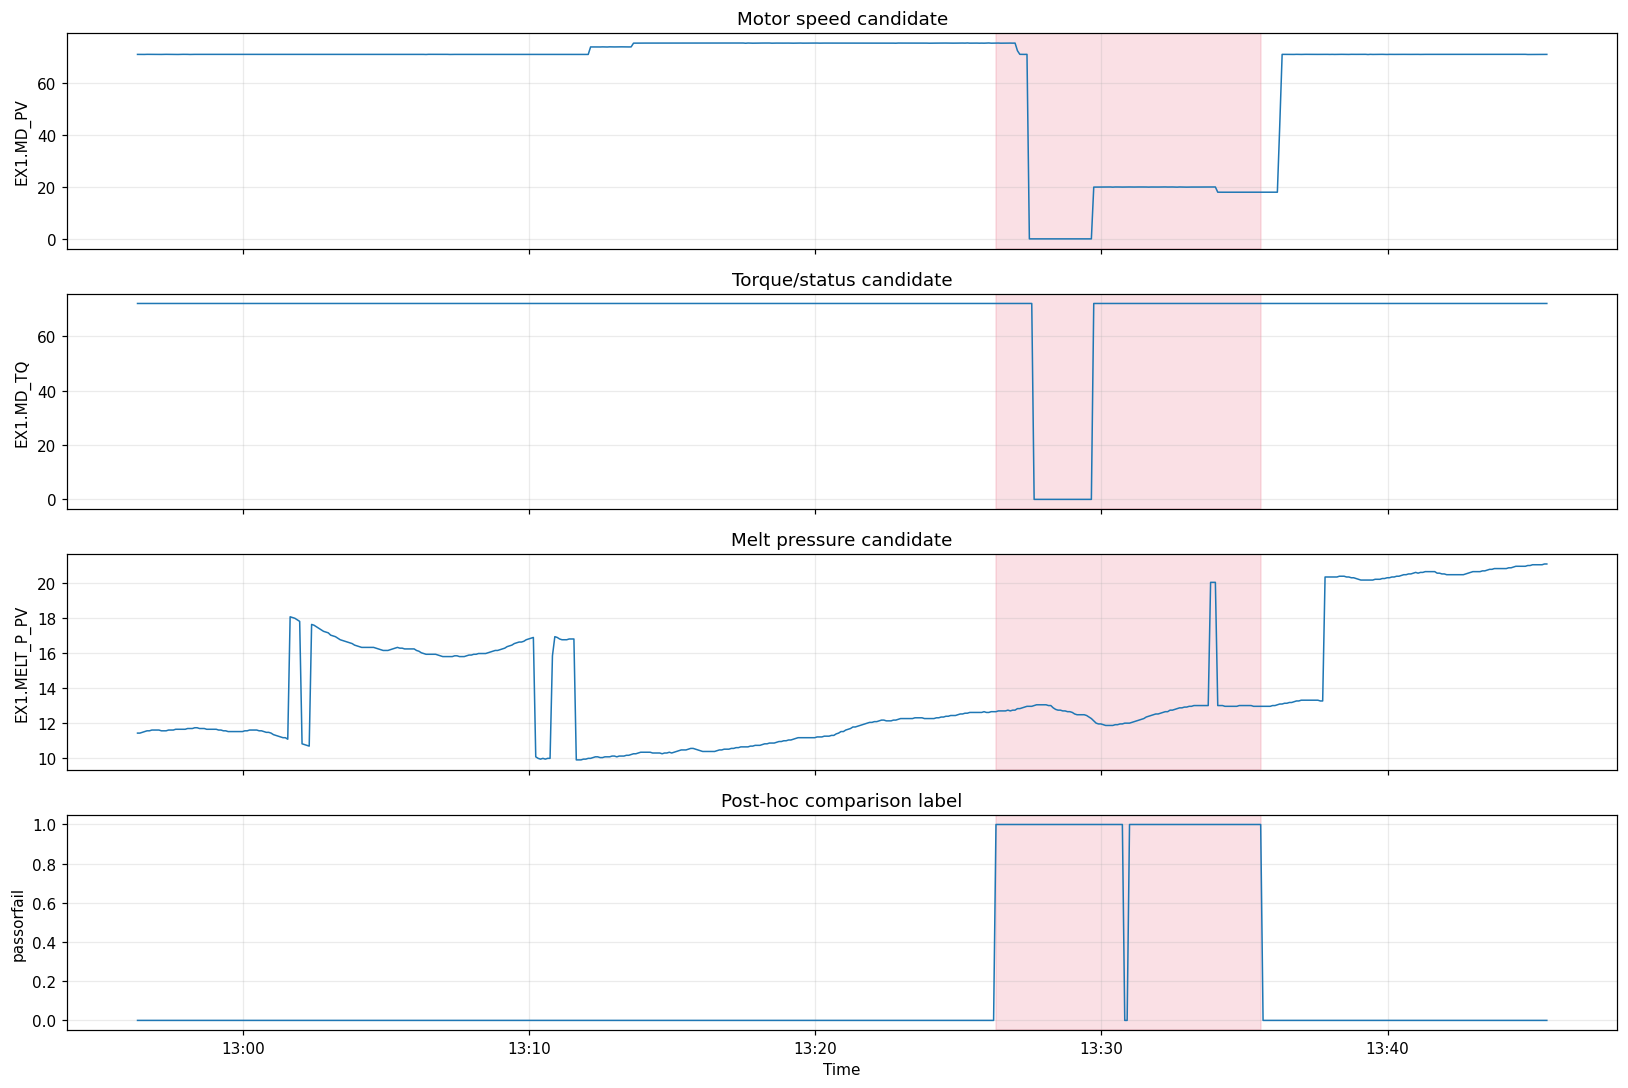

In [15]:
# Event-window Time Alignment
# Domain connection: 13:12 속도 변화가 제품에 반영되는 시점은 재료 체류시간 없이는 확정할 수 없다.
window_start = event_start - pd.Timedelta(minutes=30)
window_end = event_end + pd.Timedelta(minutes=10)
window_mask = df["timestamp"].between(window_start, window_end)
event_window = df.loc[window_mask].copy()

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
series_to_plot = [
    ("EX1.MD_PV", "Motor speed candidate"),
    ("EX1.MD_TQ", "Torque/status candidate"),
    ("EX1.MELT_P_PV", "Melt pressure candidate"),
    (TARGET_LIKE_COL, "Post-hoc comparison label"),
]
for axis, (column, title) in zip(axes, series_to_plot):
    axis.plot(event_window["timestamp"], event_window[column], linewidth=1.0)
    axis.axvspan(event_start, event_end, color="crimson", alpha=0.13)
    axis.set_ylabel(column)
    axis.set_title(title)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# Checkpoint
# MD_PV 변화가 첫 양성보다 앞서며 MD_TQ=0은 사건 내부에 위치하는가?

## 13. Audit-only MD_PV Deviation Segments

전후 30분을 제외한 라벨 0 구간에서 정상 평균과 표준편차를 계산한 뒤,
10σ 이상이 3행 이상 지속되는 구간을 Audit용으로 찾는다.

이 기준은 같은 하루를 보고 선택한 **사후 기술 도구**이며 운영 임계값이나 독립 검증 성능이 아니다.

,start,end,rows,lead_minutes_vs_first_positive
0,2020-10-30 13:12:09,2020-10-30 13:27:04,180,14.166667
1,2020-10-30 13:27:29,2020-10-30 13:36:14,106,-1.166667


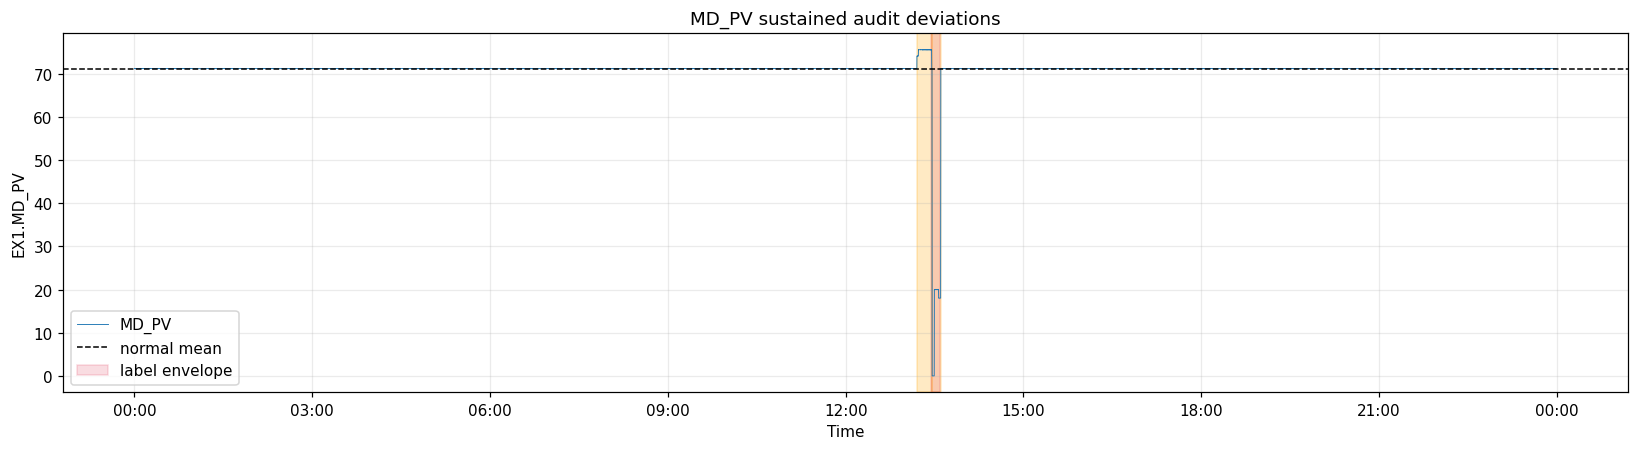

In [16]:
# Audit-only MD_PV Deviation Segments
# Domain connection: 큰 z-score는 매우 작은 정상 분산과 격자화의 결과이므로 정규분포 확률로 해석하지 않는다.
outside_30m = (
    (df["timestamp"] < event_start - pd.Timedelta(minutes=30))
    | (df["timestamp"] > event_end + pd.Timedelta(minutes=30))
)
audit_clean_normal_mask = df[TARGET_LIKE_COL].eq(0) & outside_30m & df["EX1.MD_TQ"].eq(72)

md_normal_mean = df.loc[audit_clean_normal_mask, "EX1.MD_PV"].mean()
md_normal_std = df.loc[audit_clean_normal_mask, "EX1.MD_PV"].std(ddof=1)
md_z = (df["EX1.MD_PV"] - md_normal_mean) / md_normal_std
md_10sigma_mask = md_z.abs() > 10
md_segments = state_runs(md_10sigma_mask, df["timestamp"])
md_segments = md_segments[(md_segments["value"]) & (md_segments["rows"] >= 3)].reset_index(drop=True)
md_segments["lead_minutes_vs_first_positive"] = (
    event_start - md_segments["start"]
).dt.total_seconds() / 60

print("Normal candidate rows:", int(audit_clean_normal_mask.sum()))
print("MD_PV normal mean:", round(md_normal_mean, 6))
print("MD_PV normal std:", round(md_normal_std, 6))
display(md_segments[["start", "end", "rows", "lead_minutes_vs_first_positive"]])

fig, ax = plt.subplots(figsize=(15, 4.2))
ax.plot(df["timestamp"], df["EX1.MD_PV"], linewidth=0.6, label="MD_PV")
ax.axhline(md_normal_mean, color="black", linestyle="--", linewidth=1, label="normal mean")
for _, segment in md_segments.iterrows():
    ax.axvspan(segment["start"], segment["end"], color="orange", alpha=0.23)
ax.axvspan(event_start, event_end, color="crimson", alpha=0.15, label="label envelope")
ax.set(title="MD_PV sustained audit deviations", xlabel="Time", ylabel="EX1.MD_PV")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# Checkpoint
# 첫 지속 이탈은 13:12:09이며 첫 양성보다 14.17분 앞서는가?
# 이를 곧바로 불량 원인 또는 일반화된 조기경보 성능이라고 부르지 않는다.

## 14. Relationship Audit: Raw, Difference, and Causal Detrending

원계열 상관은 공통 추세와 자기상관을 포함한다. 5초 차분과 과거/현재만 쓰는 후행 평균 잔차를 함께 비교한다.
상관은 관계 관찰이며 인과관계가 아니다.

,EX5.MELT_TEMP,EX1.H4_PV,EX1.H2O_PV,EX1.MELT_P_PV
EX5.MELT_TEMP,1.0000,-0.4141,-0.4895,-0.5414
EX1.H4_PV,-0.4141,1.0000,0.8587,0.7252
EX1.H2O_PV,-0.4895,0.8587,1.0000,0.7138
EX1.MELT_P_PV,-0.5414,0.7252,0.7138,1.0000


,EX5.MELT_TEMP,EX1.H4_PV,EX1.H2O_PV,EX1.MELT_P_PV
EX5.MELT_TEMP,1.0000,-0.0049,0.0126,0.0006
EX1.H4_PV,-0.0049,1.0000,0.0063,0.0140
EX1.H2O_PV,0.0126,0.0063,1.0000,0.0093
EX1.MELT_P_PV,0.0006,0.0140,0.0093,1.0000


,trailing_window_minutes,max_abs_pairwise_corr
0,5,0.0912
1,10,0.1498
2,30,0.3067
3,60,0.4656


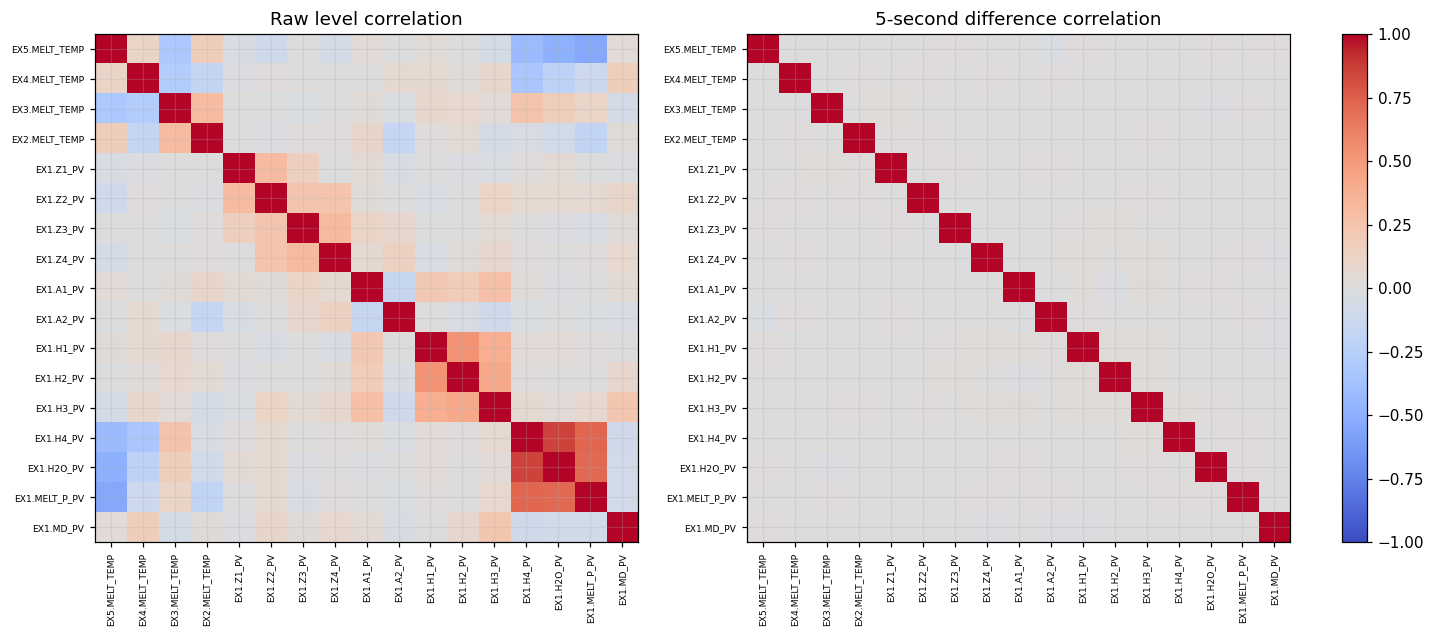

In [17]:
# Relationship Audit
# Domain connection: 단 하루의 느린 공추세를 반복되는 '일주기'라고 단정할 수 없다.
correlation_cols = [c for c in measurement_cols if df[c].nunique() > 2]
raw_corr = df[correlation_cols].corr()
diff_corr = df[correlation_cols].diff().corr()

upper_triangle = np.triu(np.ones(raw_corr.shape), k=1).astype(bool)
raw_pairs = raw_corr.where(upper_triangle).stack()
diff_pairs = diff_corr.where(upper_triangle).stack()

selected_trend_cols = [
    "EX5.MELT_TEMP", "EX1.H4_PV", "EX1.H2O_PV", "EX1.MELT_P_PV"
]
selected_raw_corr = df[selected_trend_cols].corr()
selected_diff_corr = df[selected_trend_cols].diff().corr()

print("All-feature raw maximum absolute off-diagonal correlation:", round(raw_pairs.abs().max(), 4))
print("All-feature diff maximum absolute off-diagonal correlation:", round(diff_pairs.abs().max(), 4))
print("\nSelected four — raw correlation")
display(selected_raw_corr.round(4))
print("Selected four — 5-second difference correlation")
display(selected_diff_corr.round(4))

residual_rows = []
for minutes in [5, 10, 30, 60]:
    window_rows = minutes * 12
    trailing_residual = (
        df[selected_trend_cols]
        - df[selected_trend_cols].rolling(window_rows, min_periods=window_rows).mean()
    )
    residual_corr = trailing_residual.dropna().corr()
    residual_pairs = residual_corr.where(np.triu(np.ones((4, 4)), k=1).astype(bool)).stack()
    residual_rows.append({
        "trailing_window_minutes": minutes,
        "max_abs_pairwise_corr": residual_pairs.abs().max(),
    })
residual_summary = pd.DataFrame(residual_rows)
display(residual_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, matrix, title in [
    (axes[0], raw_corr, "Raw level correlation"),
    (axes[1], diff_corr, "5-second difference correlation"),
]:
    image = axis.imshow(matrix, vmin=-1, vmax=1, cmap="coolwarm", aspect="auto")
    axis.set_xticks(range(len(correlation_cols)))
    axis.set_yticks(range(len(correlation_cols)))
    axis.set_xticklabels(correlation_cols, rotation=90, fontsize=6)
    axis.set_yticklabels(correlation_cols, fontsize=6)
    axis.set_title(title)
fig.colorbar(image, ax=axes, fraction=0.025, pad=0.04)
plt.show()

# Checkpoint
# 핵심 네 변수의 raw 상관은 크지만 차분 상관은 최대 약 0.014인가?
# 차분 상관이 약하다는 사실만으로 시차·비선형·저주파 관계를 모두 부정하지 않는다.

## 15. Candidate Derived Variables

H4 정체가 미확정이므로 다이 균일도 후보는 H1–H3로 제한한다.
압력 변화량은 5초와 60초 기준을 따로 계산하고 사건 특이성이 있는지 확인한다.

period,normal_outside_30m,positive_rows,post_10m,pre_10m
feature,,,,
die_temp_range_h1_h3,0.4356,1.8545,2.2500,0.3083
die_temp_range_h1_h4_sensitivity,199.5536,197.1727,198.6000,198.0000
die_temp_std_h1_h3,0.2045,0.7925,0.9554,0.1453
md_speed_abs_z_audit_only,0.8055,3504.5966,232.7380,303.3086
pressure_abs_change_60s,0.5884,0.6654,0.8604,0.2242
pressure_change_5s,-0.0002,0.0024,0.0678,0.0190


,timestamp,pressure_change_5s,passorfail
10105,2020-10-30 14:02:09,-7.2625,0.0
11668,2020-10-30 16:12:24,7.2188,0.0
11975,2020-10-30 16:37:59,7.2188,0.0
12153,2020-10-30 16:52:49,7.2187,0.0
11849,2020-10-30 16:27:29,7.2187,0.0
12399,2020-10-30 17:13:19,7.2187,0.0
10129,2020-10-30 14:04:09,7.1750,0.0
12805,2020-10-30 17:47:09,7.1750,0.0
11737,2020-10-30 16:18:09,7.1750,0.0
9813,2020-10-30 13:37:49,7.0875,0.0


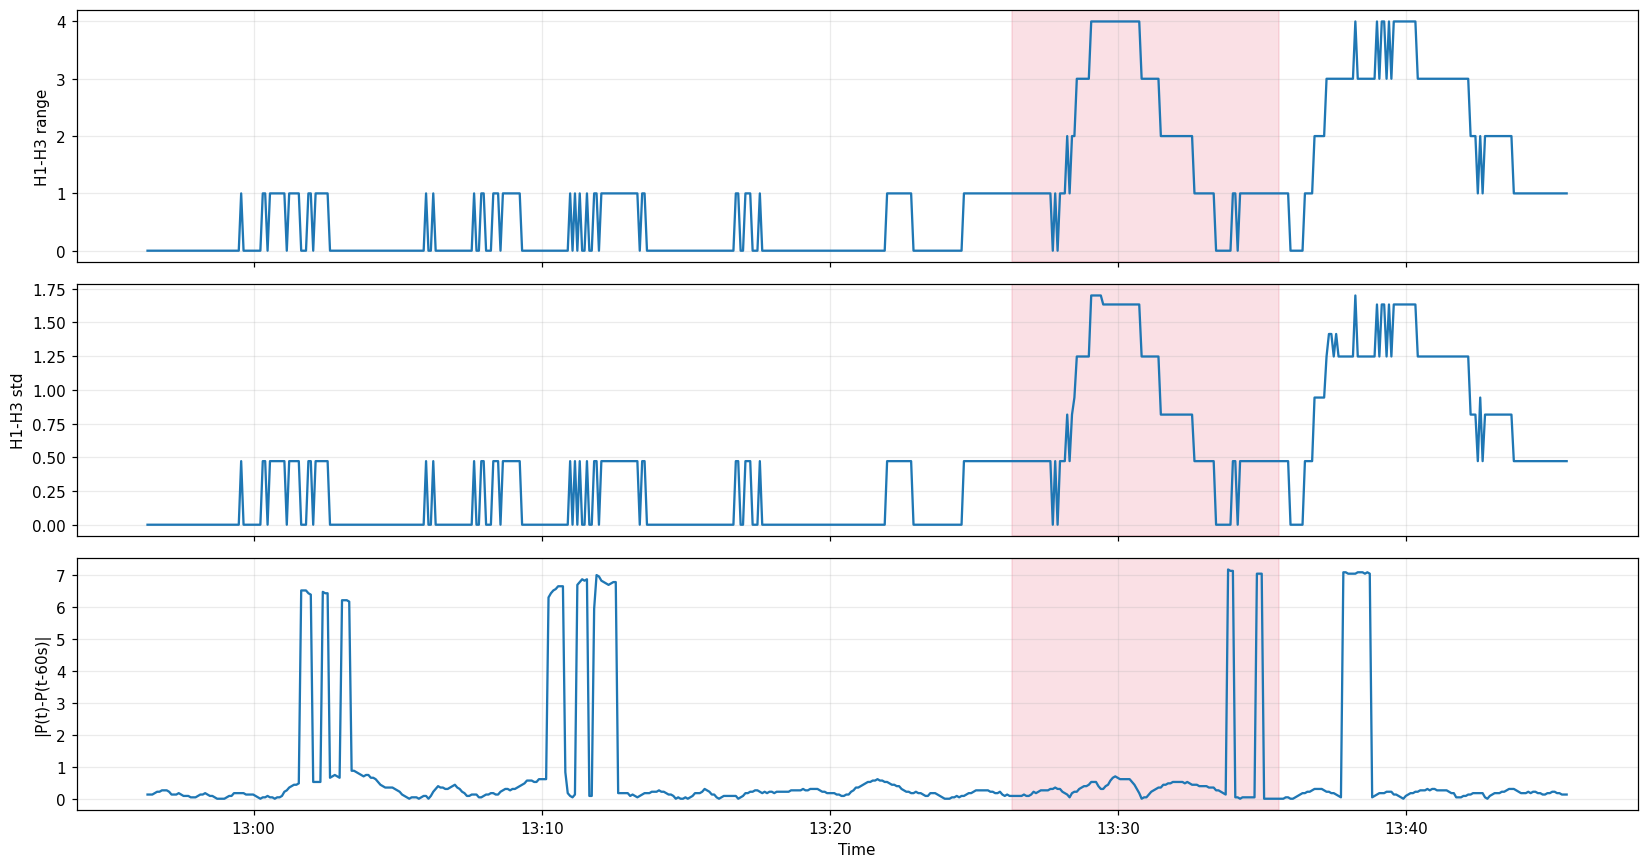

In [18]:
# Candidate Derived Variables
# Domain connection: H4를 포함한 range는 위치 차이가 아니라 약 200의 scale 차이를 측정할 위험이 있다.
h1_h3_cols = ["EX1.H1_PV", "EX1.H2_PV", "EX1.H3_PV"]
h1_h4_cols = h1_h3_cols + ["EX1.H4_PV"]

derived = pd.DataFrame(index=df.index)
derived["die_temp_range_h1_h3"] = df[h1_h3_cols].max(axis=1) - df[h1_h3_cols].min(axis=1)
derived["die_temp_std_h1_h3"] = df[h1_h3_cols].std(axis=1, ddof=0)
derived["die_temp_range_h1_h4_sensitivity"] = df[h1_h4_cols].max(axis=1) - df[h1_h4_cols].min(axis=1)
derived["pressure_change_5s"] = df["EX1.MELT_P_PV"].diff()
derived["pressure_abs_change_60s"] = df["EX1.MELT_P_PV"].diff(12).abs()
derived["md_speed_abs_z_audit_only"] = md_z.abs()

comparison_masks = {
    "normal_outside_30m": audit_clean_normal_mask,
    "pre_10m": df["timestamp"].between(event_start - pd.Timedelta(minutes=10), event_start, inclusive="left"),
    "positive_rows": positive_mask,
    "post_10m": df["timestamp"].between(event_end, event_end + pd.Timedelta(minutes=10), inclusive="right") & ~positive_mask,
}

derived_rows = []
for feature in derived.columns:
    for period, mask in comparison_masks.items():
        derived_rows.append({
            "feature": feature,
            "period": period,
            "mean": derived.loc[mask, feature].mean(),
            "p95": derived.loc[mask, feature].quantile(0.95),
            "max": derived.loc[mask, feature].max(),
        })
derived_summary = pd.DataFrame(derived_rows)
display(derived_summary.pivot(index="feature", columns="period", values="mean").round(4))

top_pressure_changes = derived["pressure_change_5s"].abs().nlargest(12).index
top_pressure_table = pd.DataFrame({
    "timestamp": df.loc[top_pressure_changes, "timestamp"],
    "pressure_change_5s": derived.loc[top_pressure_changes, "pressure_change_5s"],
    "passorfail": df.loc[top_pressure_changes, TARGET_LIKE_COL],
}).sort_values("pressure_change_5s", key=lambda s: s.abs(), ascending=False)
display(top_pressure_table)

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)
event_index = event_window.index
axes[0].plot(df.loc[event_index, "timestamp"], derived.loc[event_index, "die_temp_range_h1_h3"])
axes[0].set_ylabel("H1-H3 range")
axes[1].plot(df.loc[event_index, "timestamp"], derived.loc[event_index, "die_temp_std_h1_h3"])
axes[1].set_ylabel("H1-H3 std")
axes[2].plot(df.loc[event_index, "timestamp"], derived.loc[event_index, "pressure_abs_change_60s"])
axes[2].set_ylabel("|P(t)-P(t-60s)|")
for axis in axes:
    axis.axvspan(event_start, event_end, color="crimson", alpha=0.13)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

# Checkpoint
# H1–H3 range/std는 사건 구간에서 커지는가?
# 큰 pressure change가 사건 밖에도 많아 단독 선행신호로 특이적이지 않은가?

## 16. Buffer and Autocorrelation Sensitivity

완충 0–30분에서 정상 학습 후보 행 수와 MD_PV 이탈 잔존량을 계산한다.
raw 자기상관은 10분 완충의 보편적 근거가 되는지도 확인한다.

In [19]:
# Buffer Sensitivity
# Domain connection: 라벨보다 14.17분 앞선 MD_PV 이탈이 있으므로 10분 buffer는 일부 오염을 남길 수 있다.
buffer_rows = []
for buffer_minutes in [0, 5, 10, 15, 20, 30]:
    exclusion_start = event_start - pd.Timedelta(minutes=buffer_minutes)
    exclusion_end = event_end + pd.Timedelta(minutes=buffer_minutes)
    candidate_normal = (
        df[TARGET_LIKE_COL].eq(0)
        & ((df["timestamp"] < exclusion_start) | (df["timestamp"] > exclusion_end))
    )
    buffer_rows.append({
        "buffer_minutes": buffer_minutes,
        "candidate_normal_rows": int(candidate_normal.sum()),
        "excluded_rows_from_all": int(len(df) - candidate_normal.sum()),
        "pressure_zero_rows_retained": int((candidate_normal & pressure_zero_mask).sum()),
        "MD_PV_10sigma_rows_retained": int((candidate_normal & md_10sigma_mask).sum()),
    })
buffer_table = pd.DataFrame(buffer_rows)
display(buffer_table)

# Raw autocorrelation at operationally interpretable lags
acf_rows = []
for column in measurement_cols:
    row = {"column": column}
    for minutes in [1, 5, 10, 30, 60]:
        row[f"acf_{minutes}m"] = df[column].autocorr(minutes * 12)
    acf_rows.append(row)
acf_table = pd.DataFrame(acf_rows).set_index("column")
display(acf_table.round(4))

below_point_one_at_10m = int((acf_table["acf_10m"].abs() < 0.1).sum())
print("Features with |raw ACF at 10 min| < 0.1:", below_point_one_at_10m, "/", len(acf_table))

# Checkpoint
# 10분 buffer에 MD_PV 이탈 50행이 남고 15분부터 0행인가?
# raw 10분 ACF가 0.1 미만인 열은 18개 중 8개뿐인가?

,buffer_minutes,candidate_normal_rows,excluded_rows_from_all,pressure_zero_rows_retained,MD_PV_10sigma_rows_retained
0,0,17152,128,4400,178
1,5,17032,248,4400,110
2,10,16912,368,4400,50
3,15,16792,488,4400,0
4,20,16672,608,4400,0
5,30,16432,848,4400,0


,acf_1m,acf_5m,acf_10m,acf_30m,acf_60m
column,,,,,
EX5.MELT_TEMP,0.8853,0.7192,0.6657,0.5580,0.4960
EX4.MELT_TEMP,0.7001,0.3598,0.1522,0.1344,0.0060
EX3.MELT_TEMP,0.7977,0.5218,0.3909,0.1296,0.0889
EX2.MELT_TEMP,0.8495,0.4672,0.2474,0.0035,-0.0175
EX1.Z1_PV,0.5599,-0.2557,-0.0498,-0.0826,-0.0231
EX1.Z2_PV,0.5069,-0.1114,-0.0564,-0.0046,-0.0240
EX1.Z3_PV,0.3276,-0.0153,-0.0181,-0.0123,0.0152
EX1.Z4_PV,0.4344,-0.0472,-0.0722,-0.0211,-0.0022
EX1.A1_PV,0.4629,-0.0646,-0.0747,0.0121,0.0247


## 17. Provisional Normal-state Definition

`audit_clean_normal`은 물리적으로 정상이라는 확정이 아니라, 현재 정보로 사건 오염을 보수적으로 줄인 학습 후보이다.

- `passorfail == 0`
- 첫 양성 30분 전부터 마지막 양성 30분 후까지 제외
- 결측 라벨 제외
- `MD_TQ == 72`

압력 0의 물리적 의미가 확인될 때까지 다음 두 버전을 병렬 유지한다.

- Normal-A: 압력 0 포함
- Normal-B: 압력 0 제외

In [20]:
# Provisional Normal-state Counts
normal_a_mask = audit_clean_normal_mask
normal_b_mask = audit_clean_normal_mask & ~pressure_zero_mask
normal_definition_table = pd.DataFrame({
    "definition": ["Normal-A: pressure zero included", "Normal-B: pressure zero excluded"],
    "rows": [int(normal_a_mask.sum()), int(normal_b_mask.sum())],
    "pct_of_all_rows": [normal_a_mask.mean() * 100, normal_b_mask.mean() * 100],
})
display(normal_definition_table.round(3))
print(
    "Pressure-zero share inside Normal-A:",
    round((normal_a_mask & pressure_zero_mask).sum() / normal_a_mask.sum() * 100, 3),
    "%",
)

# Domain connection: Normal-A/B의 결과 차이가 무압 구간 사용 여부의 민감도를 보여준다.
# Checkpoint
# Normal-A가 16,432행이며 그중 pressure zero가 4,400행인가?

,definition,rows,pct_of_all_rows
0,Normal-A: pressure zero included,16432,95.093
1,Normal-B: pressure zero excluded,12032,69.630


## 18. Data Risk Map

위험 등급은 모델 성능이 아니라 현재 데이터로 신뢰할 수 있는 결론의 범위를 나타낸다.

In [21]:
# Data Risk Map
risk_map = pd.DataFrame([
    ["Label quality", "HIGH", "양성 두 구간, 10초 0 공백, 마지막 16행 결측", "라벨 생성·병합 규칙 확인"],
    ["Event scarcity", "HIGH", "한 날짜, 사실상 알려진 사건 1건", "추가 날짜/사건 확보; 일반화 주장 제한"],
    ["Time leakage", "HIGH", "강한 자기상관과 사건 주변 레짐 변화", "시간 순서 보존; causal feature만 사용"],
    ["Training contamination", "HIGH", "10분 buffer에 MD 이탈 50행 잔존", "0–30분 민감도; 대표 설정 사전 고정"],
    ["Timestamp leakage", "HIGH", "사건이 하루 특정 시각에만 존재", "원시 시각을 모델 feature로 쓰지 않기"],
    ["Pressure regime ambiguity", "HIGH", "압력 0이 25.46%, 물리적 의미 미확정", "Normal-A/B 병렬 분석과 도메인 확인"],
    ["Sensor semantics", "HIGH", "H4·MD_TQ·단위·위치 미확정", "tag dictionary/설비 담당자 확인"],
    ["Duplicate leakage", "MEDIUM", "센서 벡터 반복과 인접 유사 행", "random row split 및 중복 삭제 금지"],
    ["Preprocessing leakage", "HIGH", "full-day 평균·trend·threshold fit 위험", "훈련 구간에만 fit, 이후 transform"],
    ["Distribution shift", "UNKNOWN/HIGH", "다른 날짜·재료·설비 자료 없음", "외부 날짜/LOT 검증"],
    ["Causal interpretation", "HIGH", "13:12 변화 주체·체류시간 미확정", "원인 대신 선행 관찰로 표현"],
    ["Group leakage", "UNKNOWN", "machine/LOT/material ID 없음", "원 데이터 metadata 확보"],
], columns=["risk", "level", "evidence", "required_action"])
display(risk_map)

# Checkpoint
# 위험마다 데이터 근거와 다음 조치가 연결되어 있는가?

,risk,level,evidence,required_action
0,Label quality,HIGH,"양성 두 구간, 10초 0 공백, 마지막 16행 결측",라벨 생성·병합 규칙 확인
1,Event scarcity,HIGH,"한 날짜, 사실상 알려진 사건 1건",추가 날짜/사건 확보; 일반화 주장 제한
2,Time leakage,HIGH,강한 자기상관과 사건 주변 레짐 변화,시간 순서 보존; causal feature만 사용
3,Training contamination,HIGH,10분 buffer에 MD 이탈 50행 잔존,0–30분 민감도; 대표 설정 사전 고정
4,Timestamp leakage,HIGH,사건이 하루 특정 시각에만 존재,원시 시각을 모델 feature로 쓰지 않기
5,Pressure regime ambiguity,HIGH,"압력 0이 25.46%, 물리적 의미 미확정",Normal-A/B 병렬 분석과 도메인 확인
6,Sensor semantics,HIGH,H4·MD_TQ·단위·위치 미확정,tag dictionary/설비 담당자 확인
7,Duplicate leakage,MEDIUM,센서 벡터 반복과 인접 유사 행,random row split 및 중복 삭제 금지
8,Preprocessing leakage,HIGH,full-day 평균·trend·threshold fit 위험,"훈련 구간에만 fit, 이후 transform"
9,Distribution shift,UNKNOWN/HIGH,다른 날짜·재료·설비 자료 없음,외부 날짜/LOT 검증


## 19. Data Audit Findings

아래 셀은 계산 결과를 요약한다. 관찰과 결정을 분리하며, 미확정 물리 해석은 남겨 둔다.

In [22]:
# Final Findings Generated from Audit Results
first_md_segment = md_segments.iloc[0]
h13_normal_mean = derived.loc[audit_clean_normal_mask, "die_temp_range_h1_h3"].mean()
h13_positive_mean = derived.loc[positive_mask, "die_temp_range_h1_h3"].mean()
pressure_zero_pct = pressure_zero_mask.mean() * 100

display(Markdown(f'''
### Dataset Structure

- Rows: **{len(df_raw):,}**
- Columns: **{len(df_raw.columns)}** (`date` 1 + sensors 18 + comparison label 1)
- Analysis unit: 5초 시점의 연속 공정 snapshot
- Time integrity: {df['timestamp'].min()}–{df['timestamp'].max()}, 모든 간격 5초

### Missing and Duplicates

- Sensor NaN: **0**
- Missing `passorfail`: **{df[TARGET_LIKE_COL].isna().sum()} rows**
- Full duplicate rows: **{full_duplicates}**
- Repeated 18-sensor vectors: **{measurement_vector_duplicates:,} rows** — 삭제하지 않음

### Comparison Label

- Positive rows: **{positive_mask.sum()}** ({positive_pct_nonmissing:.4f}% of observed labels)
- 두 양성 구간 사이에 0 라벨 2행(10초)이 있으므로 사건 병합 규칙이 필요함

### Domain-linked Findings

1. `MD_PV` 첫 지속 이탈: **{first_md_segment['start']}**, 첫 양성보다 **{first_md_segment['lead_minutes_vs_first_positive']:.2f}분** 앞섬.
2. `MD_TQ`: 0/72 두 값이며 0인 25행은 모두 `MD_PV=0`; 연속 torque로 사용하지 않음.
3. Pressure zero: **{pressure_zero_mask.sum():,} rows ({pressure_zero_pct:.2f}%)**, {len(pressure_zero_runs)} runs; 자동 결측 처리하지 않음.
4. H1–H3 range 평균: 정상 후보 {h13_normal_mean:.3f} → 양성행 {h13_positive_mean:.3f}; 한 사건의 사례 관찰임.
5. 핵심 4변수 raw 최대 절대 상관 {selected_raw_corr.where(np.triu(np.ones((4,4)),1).astype(bool)).stack().abs().max():.4f}, 차분 후 {selected_diff_corr.where(np.triu(np.ones((4,4)),1).astype(bool)).stack().abs().max():.4f}; 저주파 공추세가 지배적임.

### Items Requiring Confirmation

1. 재료 체류시간과 13:12 변화의 주체
2. `passorfail` 생성·경계·10초 공백 규칙
3. 무압 구간의 물리적 상태
4. H4 센서 위치·단위
5. MD_TQ 태그 정의
6. EX5 장기 동일값의 정상 운전/센서 고착 여부

### Decisions Intentionally NOT Made Here

- feature 삭제·결측 대체·검증 분할·지표·model training
- 10σ를 운영 임계값으로 확정
- “14.17분 선행”을 인과적 불량 조기검출로 표현
- PCA/T²/SPE를 영구 폐기
- 한 날짜의 공추세를 일주기라고 명명
'''))

# Final Checkpoint
# 현재 어떤 사실을 확인했고, 어떤 판단은 근거가 부족하며, 다음 실험 전에 무엇을 결정해야 하는가?


### Dataset Structure

- Rows: **17,280**
- Columns: **20** (`date` 1 + sensors 18 + comparison label 1)
- Analysis unit: 5초 시점의 연속 공정 snapshot
- Time integrity: 2020-10-30 00:00:04–2020-10-30 23:59:59, 모든 간격 5초

### Missing and Duplicates

- Sensor NaN: **0**
- Missing `passorfail`: **16 rows**
- Full duplicate rows: **0**
- Repeated 18-sensor vectors: **2,426 rows** — 삭제하지 않음

### Comparison Label

- Positive rows: **110** (0.6372% of observed labels)
- 두 양성 구간 사이에 0 라벨 2행(10초)이 있으므로 사건 병합 규칙이 필요함

### Domain-linked Findings

1. `MD_PV` 첫 지속 이탈: **2020-10-30 13:12:09**, 첫 양성보다 **14.17분** 앞섬.
2. `MD_TQ`: 0/72 두 값이며 0인 25행은 모두 `MD_PV=0`; 연속 torque로 사용하지 않음.
3. Pressure zero: **4,400 rows (25.46%)**, 36 runs; 자동 결측 처리하지 않음.
4. H1–H3 range 평균: 정상 후보 0.436 → 양성행 1.855; 한 사건의 사례 관찰임.
5. 핵심 4변수 raw 최대 절대 상관 0.8587, 차분 후 0.0140; 저주파 공추세가 지배적임.

### Items Requiring Confirmation

1. 재료 체류시간과 13:12 변화의 주체
2. `passorfail` 생성·경계·10초 공백 규칙
3. 무압 구간의 물리적 상태
4. H4 센서 위치·단위
5. MD_TQ 태그 정의
6. EX5 장기 동일값의 정상 운전/센서 고착 여부

### Decisions Intentionally NOT Made Here

- feature 삭제·결측 대체·검증 분할·지표·model training
- 10σ를 운영 임계값으로 확정
- “14.17분 선행”을 인과적 불량 조기검출로 표현
- PCA/T²/SPE를 영구 폐기
- 한 날짜의 공추세를 일주기라고 명명


## 20. Next Gate

다음에 이어질 과정으로 Label and Availability를 확인하는 것이다.

도메인 답변 전에도 가능한 안전한 다음 실험:

1. Normal-A/B에서 같은 정상 예측 잔차 기준 비교
2. 0–30분 buffer 민감도 비교
3. 미래값을 쓰지 않는 후행 5분/10분 detrending 비교
4. MD_PV 단일 관리도 대비 H1–H3 range/std의 ablation
5. 고정 임계값 하나보다 정상 오탐시간–선행시간 곡선 작성

핵심 질문:

> MD_PV가 이미 알려진 사건을 거의 완전히 설명할 때, 더 복잡한 모델이 새로운 정보를 제공하는가?